-------------------------------
-------------------------------
# Proyecto 2 - Minería de Datos (CC3074)
* Dulce Ambrosio - 231143
* Daniel Chet - 231177
* Javier Linares - 231135
* Cristian Túnchez - 231359

-------------------------------
-------------------------------

-------------------------------
**Semana 1:** Comprensión del Problema y EDA  

-------------------------------

In [1]:
# ======================
# Importación de librerías
# ======================
# pandas / numpy: manipulación numérica y de tablas
# matplotlib / seaborn: visualización exploratoria (EDA)

# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set(style="whitegrid")

In [2]:
# ======================
# Carga inicial del dataset
# ======================

# Cargar el dataset
df = pd.read_csv("Datos.csv")

# Vista rápida, valida que se cargó correctamente y revisa columnas/valores iniciales
df.head()

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [3]:
# ======================
# Estructura del dataset
# ======================
# df.info() permite revisar:
# - número de filas/columnas
# - tipos de datos por columna
# - conteo de valores no nulos (detecta datos faltantes)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Sample code number           683 non-null    int64
 1   Clump Thickness              683 non-null    int64
 2   Uniformity of Cell Size      683 non-null    int64
 3   Uniformity of Cell Shape     683 non-null    int64
 4   Marginal Adhesion            683 non-null    int64
 5   Single Epithelial Cell Size  683 non-null    int64
 6   Bare Nuclei                  683 non-null    int64
 7   Bland Chromatin              683 non-null    int64
 8   Normal Nucleoli              683 non-null    int64
 9   Mitoses                      683 non-null    int64
 10  Class                        683 non-null    int64
dtypes: int64(11)
memory usage: 58.8 KB


In [4]:
# ======================
# Estadísticas descriptivas
# ======================
# describe() resume variables numéricas: media, desviación, percentiles, etc.
# Sirve para detectar rangos anómalos o escalas muy diferentes.
df.describe()

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
count,6.830000e+02,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,1.076720e+06,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221,2.699854
std,6.206440e+05,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674,0.954592
min,6.337500e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.776170e+05,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171795e+06,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238705e+06,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


-------------------------------
**Limpieza de Datos:** Se realiza una inspección de la variable Bare Nuclei, que en algunas versiones del dataset contiene valores faltantes representados como el carácter ?. Se aplica una conversión a numérico con errors='coerce' para transformar cualquier valor inválido en NaN, y luego se eliminan las filas incompletas con dropna().

-------------------------------

In [5]:
# ======================
# Inspección de valores en Bare Nuclei
# ======================
# Revisar unique() ayuda a confirmar si existen valores no numéricos.
print("Valores únicos en Bare Nuclei:")
print(df['Bare Nuclei'].unique())

Valores únicos en Bare Nuclei:
[ 1 10  2  4  3  9  7  5  8  6]


In [6]:
# ======================
# Limpieza: convertir 'Bare Nuclei' a numérico
# ======================
# errors='coerce' convierte valores inválidos a NaN.
df['Bare Nuclei'] = pd.to_numeric(df['Bare Nuclei'], errors='coerce')

# Diagnóstico de valores faltantes por columna
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
Sample code number             0
Clump Thickness                0
Uniformity of Cell Size        0
Uniformity of Cell Shape       0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Bland Chromatin                0
Normal Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64


In [7]:
# ======================
# Tratamiento de faltantes
# ======================
# Eliminar filas con cualquier NaN.
df = df.dropna()

# Asegurar que Class sea numérica (2/4) y no texto ('2'/'4')
df['Class'] = pd.to_numeric(df['Class'], errors='coerce')
df = df.dropna(subset=['Class'])
df['Class'] = df['Class'].astype(int)

# Confirmar que ya no hay valores nulos después de dropna()
print(f"Filas restantes después de limpiar: {len(df)}")
print("Valores nulos por columna (post-limpieza):")
print(df.isnull().sum())

Filas restantes después de limpiar: 683
Valores nulos por columna (post-limpieza):
Sample code number             0
Clump Thickness                0
Uniformity of Cell Size        0
Uniformity of Cell Shape       0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Bland Chromatin                0
Normal Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64


In [8]:
# ======================
# Eliminación de variable identificadora
# ======================
# 'Sample code number' es un identificador único sin valor predictivo.
# Se elimina antes de las visualizaciones y del modelado.
df = df.drop(columns=['Sample code number'], errors='ignore')

print(f"Columnas restantes ({len(df.columns)}): {list(df.columns)}")

Columnas restantes (10): ['Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape', 'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin', 'Normal Nucleoli', 'Mitoses', 'Class']


In [9]:
# ======================
# tipo de la variable objetivo
# ======================
print("dtype Class:", df['Class'].dtype)
print("Ejemplo de valores Class:", df['Class'].head().tolist())
print("Tipos únicos en Class:", sorted({type(x).__name__ for x in df['Class'].dropna().unique()}))
print("Valores únicos en Class:", sorted(df['Class'].dropna().unique())[:10])

dtype Class: int64
Ejemplo de valores Class: [2, 2, 2, 2, 2]
Tipos únicos en Class: ['int64']
Valores únicos en Class: [np.int64(2), np.int64(4)]


-------------------------------
**Análisis Exploratorio de Datos (EDA)** 

-------------------------------

In [10]:
# ======================
# Variable objetivo (Class)
# ======================
# value_counts() permite revisar el balance de clases (posible desbalance).
print("Distribución de clases:")
print(df['Class'].value_counts())
print(f"\nTotal de registros: {len(df)}")
print(f"Proporción benignas (2): {df['Class'].value_counts()[2] / len(df) * 100:.1f}%")
print(f"Proporción malignas (4): {df['Class'].value_counts()[4] / len(df) * 100:.1f}%")

Distribución de clases:
Class
2    444
4    239
Name: count, dtype: int64

Total de registros: 683
Proporción benignas (2): 65.0%
Proporción malignas (4): 35.0%


C:\Users\danie\AppData\Local\Temp\ipykernel_2184\2236978696.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Class', data=df, palette=['steelblue', 'steelblue'])


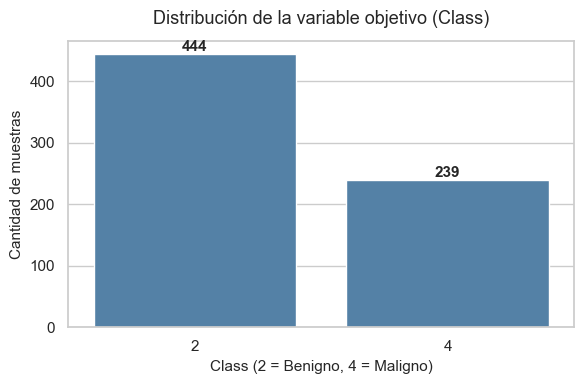

In [11]:
# ======================
# Distribución de la variable objetivo
# ======================
# countplot muestra cuántos ejemplos hay por clase.

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Class', data=df, palette=['steelblue', 'steelblue'])

# Agregar conteos encima de las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title("Distribución de la variable objetivo (Class)", fontsize=13, pad=12)
plt.xlabel("Class (2 = Benigno, 4 = Maligno)", fontsize=11)
plt.ylabel("Cantidad de muestras", fontsize=11)
plt.tight_layout()
plt.show()

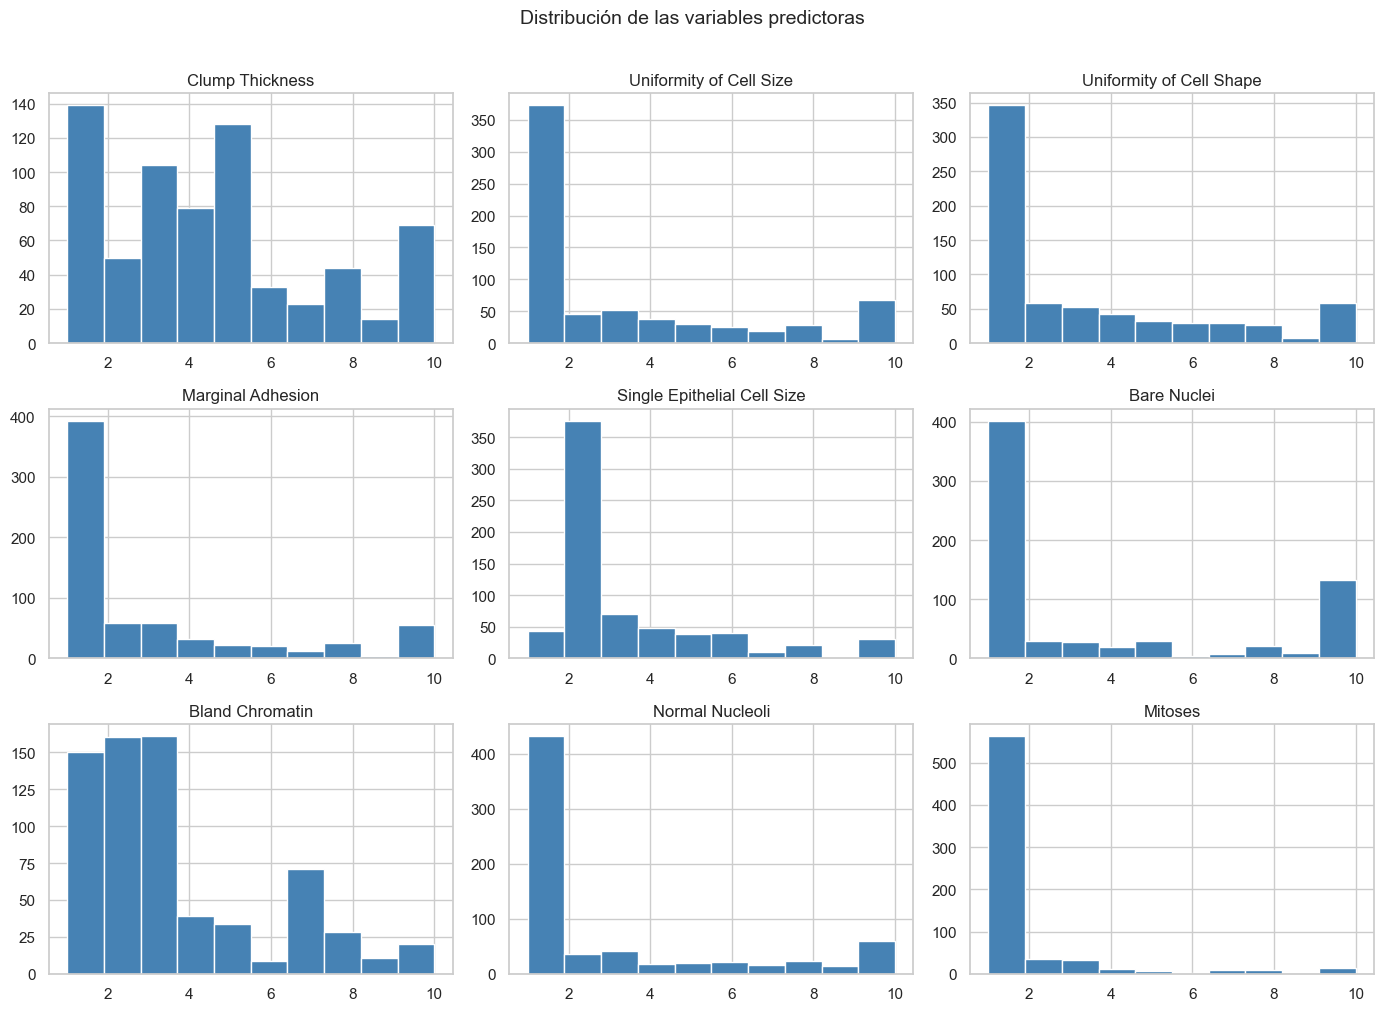

In [12]:
# ======================
# Histogramas de las variables
# ======================
# Los histogramas permiten detectar la forma de distribución de cada variable.
# Se excluye 'Class' para mostrar solo las variables predictoras.

features = [c for c in df.columns if c != 'Class']

df[features].hist(figsize=(14, 10), bins=10, edgecolor='white', color='steelblue')
plt.suptitle("Distribución de las variables predictoras", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

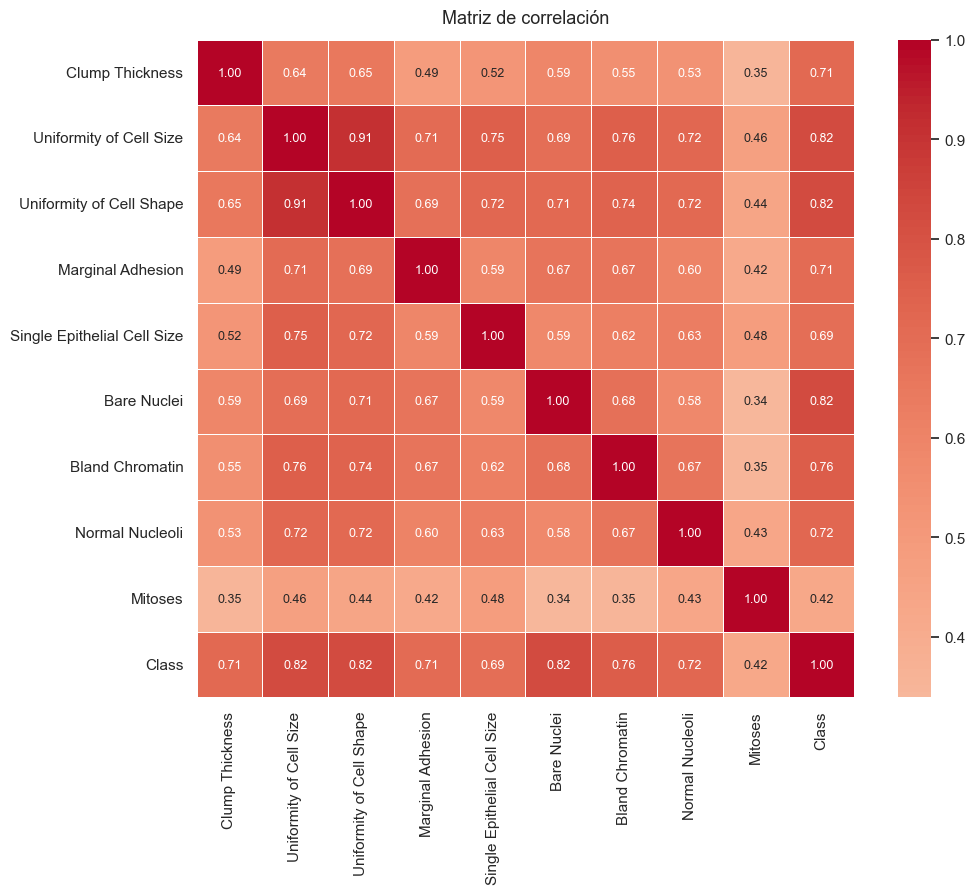

In [13]:
# ======================
# Matriz de correlación
# ======================
# Mide la relación lineal entre variables numéricas.
# Valores cercanos a 1 indican fuerte correlación positiva.

plt.figure(figsize=(11, 9))
corr_matrix = df.corr()

mask = np.zeros_like(corr_matrix, dtype=bool)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 9}
)

plt.title("Matriz de correlación", fontsize=13, pad=12)
plt.tight_layout()
plt.show()